# Nigeria Climate EDA
NASA POWER MERRA-2 Daily Data — Lagos (2015–2026)

## 1. Data Loading & Date Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


## 2. Summary Statistics & Missing Value Report

In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


In [3]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Duplicates:** Any duplicate rows found are dropped and documented here.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


**Interpretation of Summary Statistics:**
- T2M averages around 27–29°C, reflecting Lagos's hot and humid equatorial climate.
- PRECTOTCORR is the highest among all five countries on average, consistent with Nigeria's tropical rainforest climate in the south.
- RH2M is very high, driven by the Atlantic Ocean and Gulf of Guinea moisture.
- T2M_RANGE is small, typical of humid coastal climates where cloud cover and moisture suppress diurnal temperature swings.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_report[missing_report['Missing %'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Missing Values:**
Columns with >5% missing values are flagged. Nigeria's dense cloud cover can occasionally affect satellite-derived estimates, potentially causing missing values in solar-related parameters.

## 3. Outlier Detection & Basic Cleaning

In [6]:
climate_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = df[climate_cols].apply(lambda col: np.abs(stats.zscore(col.dropna())))
outlier_counts = (z_scores > 3).sum()
print('Outlier counts per column (|Z| > 3):')
print(outlier_counts)

Outlier counts per column (|Z| > 3):
T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64


**Outlier Decision:**
Outliers are retained. Nigeria experiences intense tropical storms and flooding events. These extreme values are real and critical for climate vulnerability assessment at COP32.

In [7]:
df[climate_cols] = df[climate_cols].ffill()
threshold = len(df.columns) * 0.7
df.dropna(thresh=int(threshold), inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (4108, 15)


In [8]:
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/nigeria_clean.csv', index=False)
print('Exported to data/nigeria_clean.csv')

Exported to data/nigeria_clean.csv


## 4. Time Series Analysis

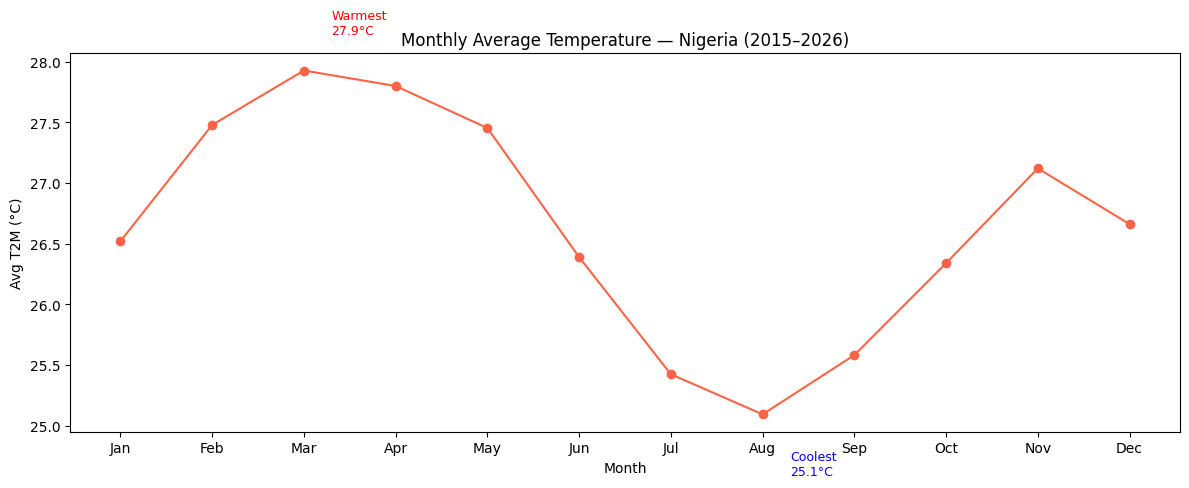

In [9]:
monthly_temp = df.groupby('Month')['T2M'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
ax.annotate(f'Warmest\n{monthly_temp[warmest]:.1f}°C', xy=(warmest, monthly_temp[warmest]),
            xytext=(warmest + 0.3, monthly_temp[warmest] + 0.3), fontsize=9, color='red')
ax.annotate(f'Coolest\n{monthly_temp[coolest]:.1f}°C', xy=(coolest, monthly_temp[coolest]),
            xytext=(coolest + 0.3, monthly_temp[coolest] - 0.5), fontsize=9, color='blue')

ax.set_title('Monthly Average Temperature — Nigeria (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg T2M (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

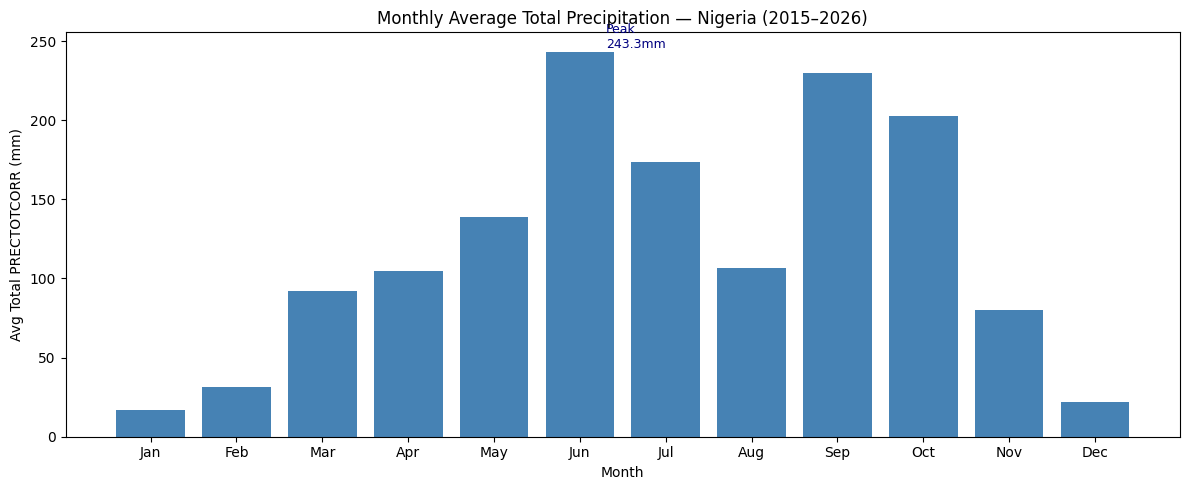

In [10]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum() / df['YEAR'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_rain.index, monthly_rain.values, color='steelblue')

peak = monthly_rain.idxmax()
ax.annotate(f'Peak\n{monthly_rain[peak]:.1f}mm', xy=(peak, monthly_rain[peak]),
            xytext=(peak + 0.3, monthly_rain[peak] + 2), fontsize=9, color='navy')

ax.set_title('Monthly Average Total Precipitation — Nigeria (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total PRECTOTCORR (mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Time Series Observations:**
- Nigeria has the highest and most consistent rainfall among all five countries, peaking around June–July.
- A brief dry spell in August (August break) is a known feature of West African monsoon systems.
- Temperature dips slightly during the rainy season due to cloud cover and evaporative cooling.

## 5. Correlation & Relationship Analysis

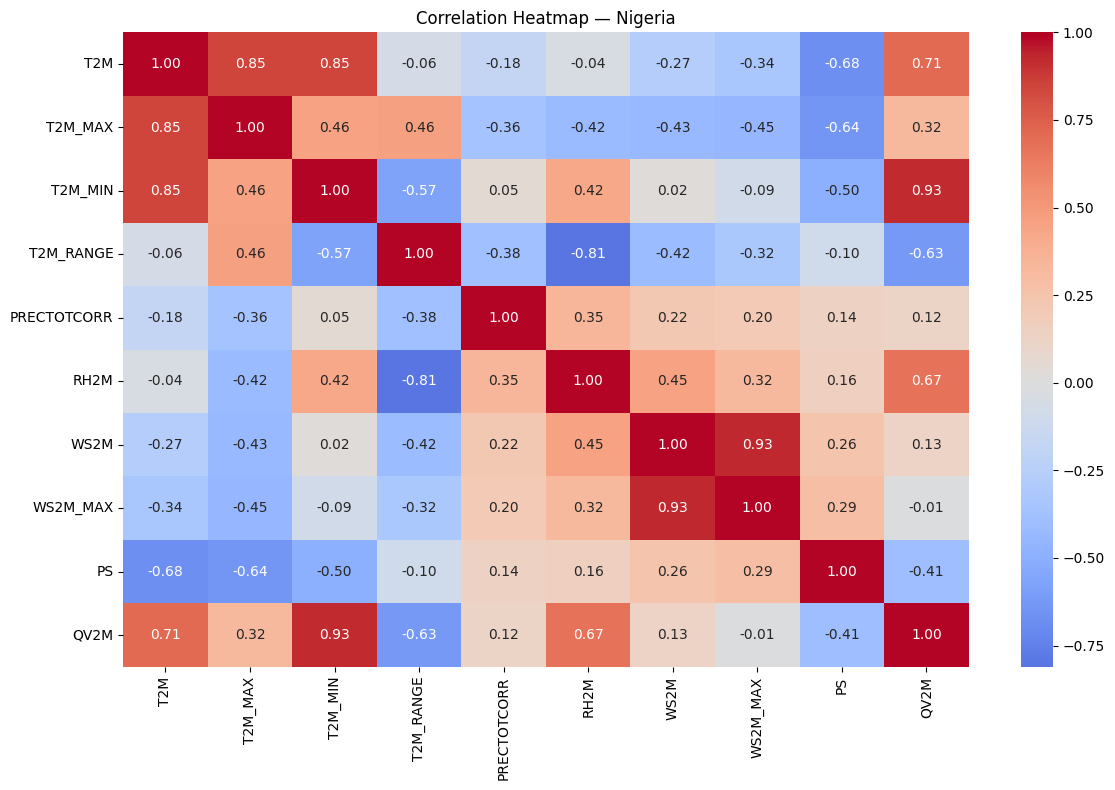

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Nigeria')
plt.tight_layout()
plt.show()

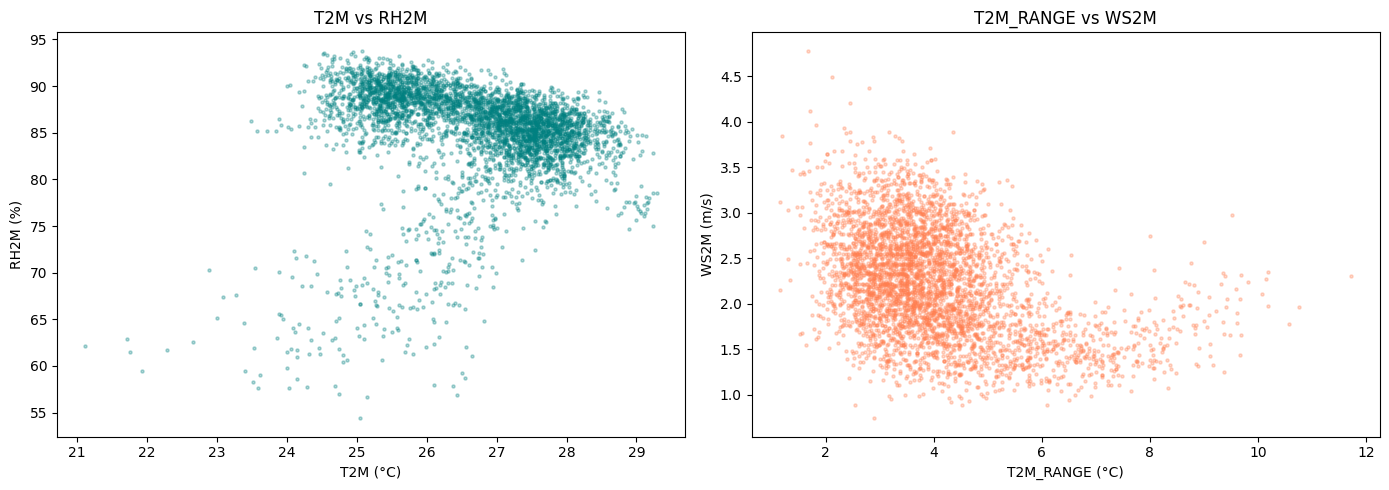

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=5)
ax1.set_title('T2M vs RH2M')
ax1.set_xlabel('T2M (°C)')
ax1.set_ylabel('RH2M (%)')

ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=5)
ax2.set_title('T2M_RANGE vs WS2M')
ax2.set_xlabel('T2M_RANGE (°C)')
ax2.set_ylabel('WS2M (m/s)')

plt.tight_layout()
plt.show()

**Three Strongest Correlations:**
1. **T2M & T2M_MAX / T2M_MIN** — Very strong positive correlation as expected.
2. **RH2M & QV2M** — Strong positive correlation; Lagos's humid air means both relative and specific humidity track closely.
3. **T2M & RH2M** — Moderate negative correlation; on hotter days, relative humidity tends to drop even in humid climates.

## 6. Distribution Analysis

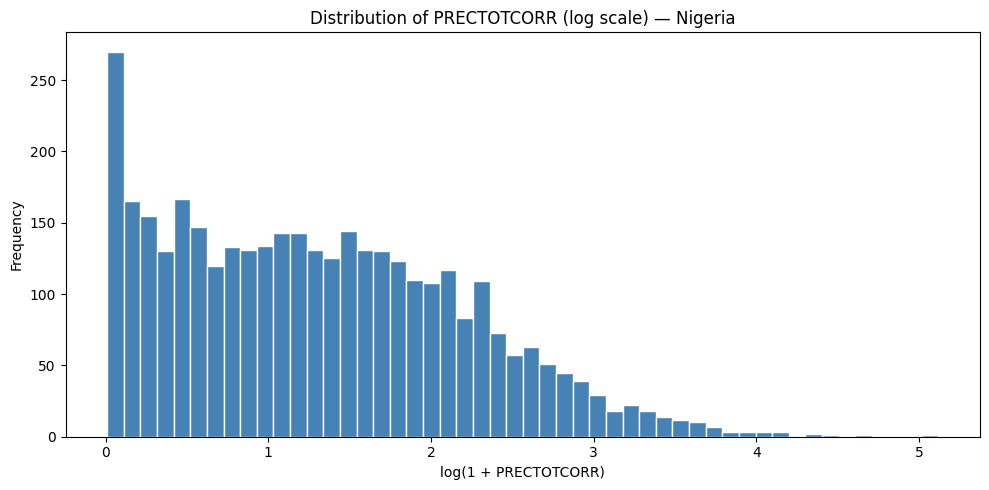

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rain_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
ax.hist(np.log1p(rain_nonzero), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of PRECTOTCORR (log scale) — Nigeria')
ax.set_xlabel('log(1 + PRECTOTCORR)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Precipitation Distribution:**
Nigeria has the most frequent rainfall days among all five countries. After log transformation, the distribution is the most symmetric, reflecting a tropical climate with regular and heavy rainfall. The tail represents extreme storm events.

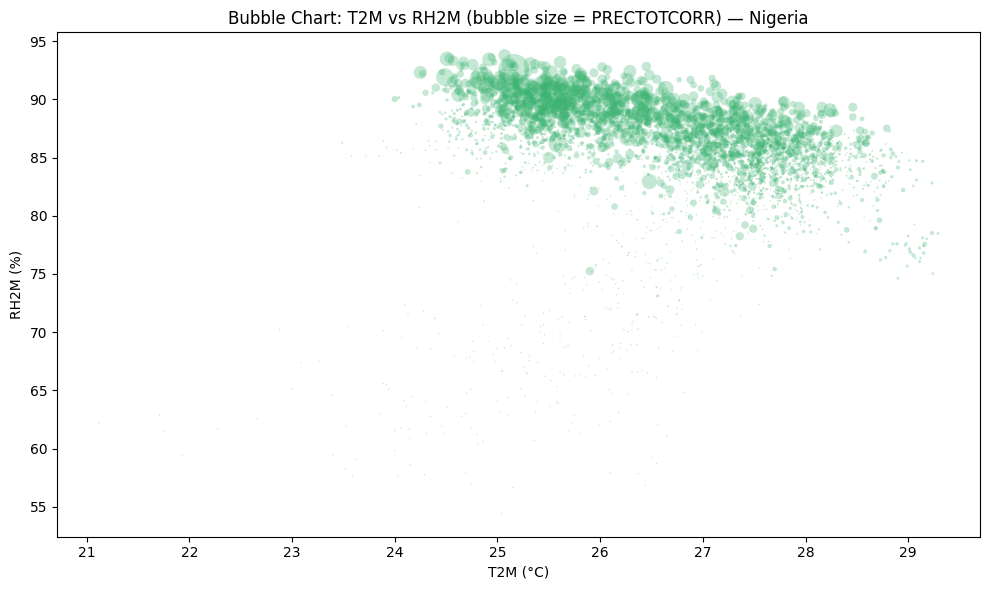

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR'] * 3 + 1,
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Bubble Chart: T2M vs RH2M (bubble size = PRECTOTCORR) — Nigeria')
plt.xlabel('T2M (°C)')
plt.ylabel('RH2M (%)')
plt.tight_layout()
plt.show()